In [76]:
import matplotlib.pyplot as plt
import numpy as np


In [77]:
# Устанавливаем шрифт CMU Serif
plt.rcParams['font.family'] = 'CMU Serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 12

In [78]:
lam = 650 * 1e-6
b = 0.52

k = 2 * np.pi / lam

sinT = np.linspace(-4 * lam / b, 4 * lam / b, 5000)
I_max = 1

lam, b, k

(0.00065, 0.52, 9666.438934122441)

In [79]:
eps = k * b / 2 * sinT / np.pi

I = I_max * np.sinc(eps)**2

In [80]:
xtitle = [n * lam / b for n in range(-4, 4+1)]

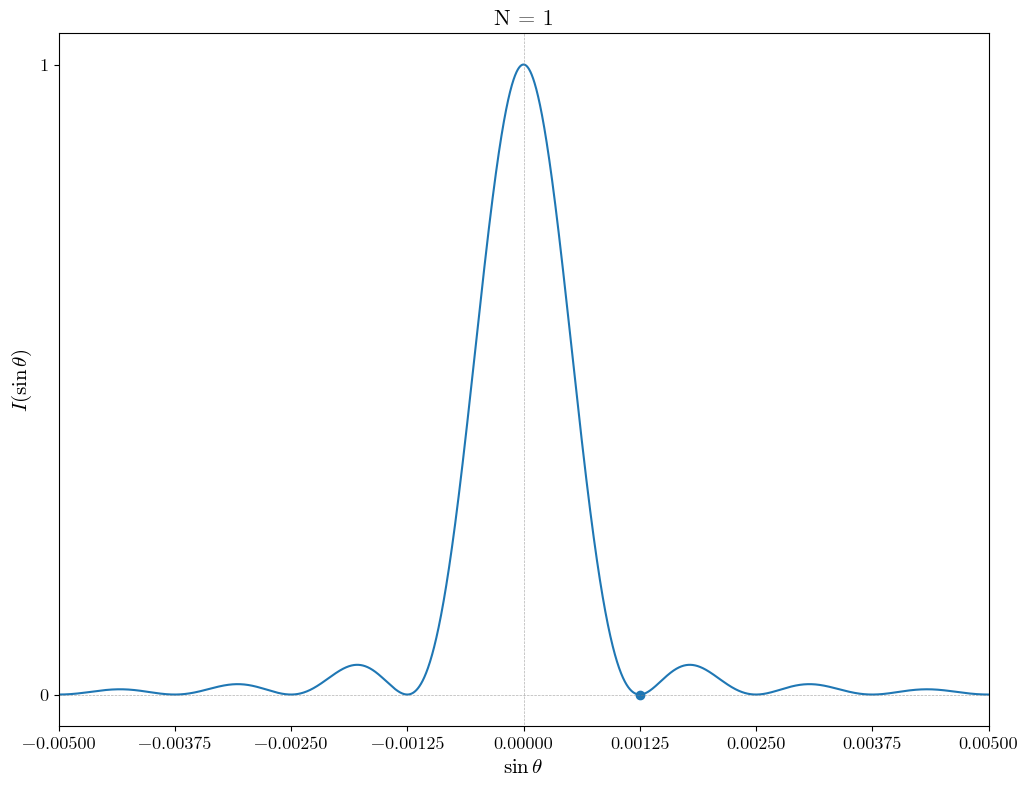

In [81]:
plt.figure(figsize=(12, 9))
plt.title("N = 1")

plt.plot(sinT, I)

plt.plot([-4 * lam / b, 4 * lam / b], [0, 0], color='gray', linestyle='--', linewidth=0.5, alpha=0.6)
plt.plot([0,0], [-1, 1.1], color='gray', linestyle='--', linewidth=0.5, alpha=0.6)

plt.scatter(lam / b, 0)

plt.xticks(xtitle)
plt.xlabel(r"$\sin \theta$")
plt.yticks([0, 1])
plt.ylabel(r"$I(\sin \theta)$")

plt.xlim(-4 * lam / b, 4 * lam / b)
plt.ylim(-0.05, 1.05)

plt.savefig('../graph/graph_N1.pdf', 
            format='pdf',
            dpi=300,
            bbox_inches='tight',  # обрезает лишние поля
            pad_inches=0.1)
plt.show()

In [82]:
d = 1.5
N = 2

eta = k * d / 2 * sinT
I_2 = I_max * np.sinc(eps)**2 * (np.sin(N * eta) / np.sin(eta))**2

In [83]:
# Главные максимумы решётки (порядки)
main_max_pos = [n * lam / d for n in range(-6, 7)]
# main_max_pos.remove(-0.0013)
# main_max_pos.remove(0.0013)
# Минимумы огибающей
min_pos = [] #[n * lam / b for n in range(-4, 5)]

# Метки — все уникальные позиции, сортированные
all_ticks = sorted(set(main_max_pos + min_pos))

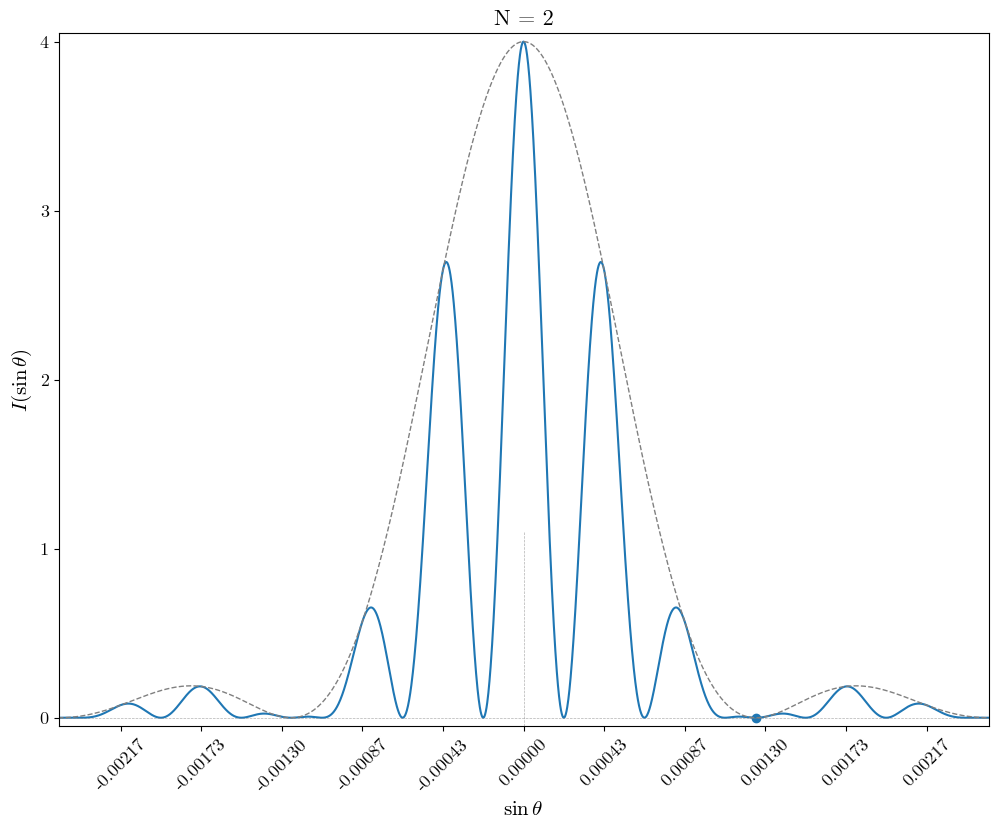

In [84]:
plt.figure(figsize=(12, 9))
plt.title("N = 2")

plt.plot(sinT, I_2)
plt.plot(sinT, N**2 * I, color='gray', linestyle='--', linewidth=1)

plt.plot([-4 * lam / b, 4 * lam / b], [0, 0], color='gray', linestyle='--', linewidth=0.5, alpha=0.6)
plt.plot([0,0], [-1, 1.1], color='gray', linestyle='--', linewidth=0.5, alpha=0.6)

plt.scatter(lam / b, 0)

plt.xticks(all_ticks, [f"{t:.5f}" for t in all_ticks], rotation=45)
plt.xlabel(r"$\sin \theta$")
plt.yticks(range(5))
plt.ylabel(r"$I(\sin \theta)$")

plt.xlim(-2 * lam / b, 2 * lam / b)
plt.ylim(-0.05, 4.05)

plt.savefig('../graph/graph_N2.pdf', 
            format='pdf',
            dpi=300,
            bbox_inches='tight',  # обрезает лишние поля
            pad_inches=0.1)
plt.show()

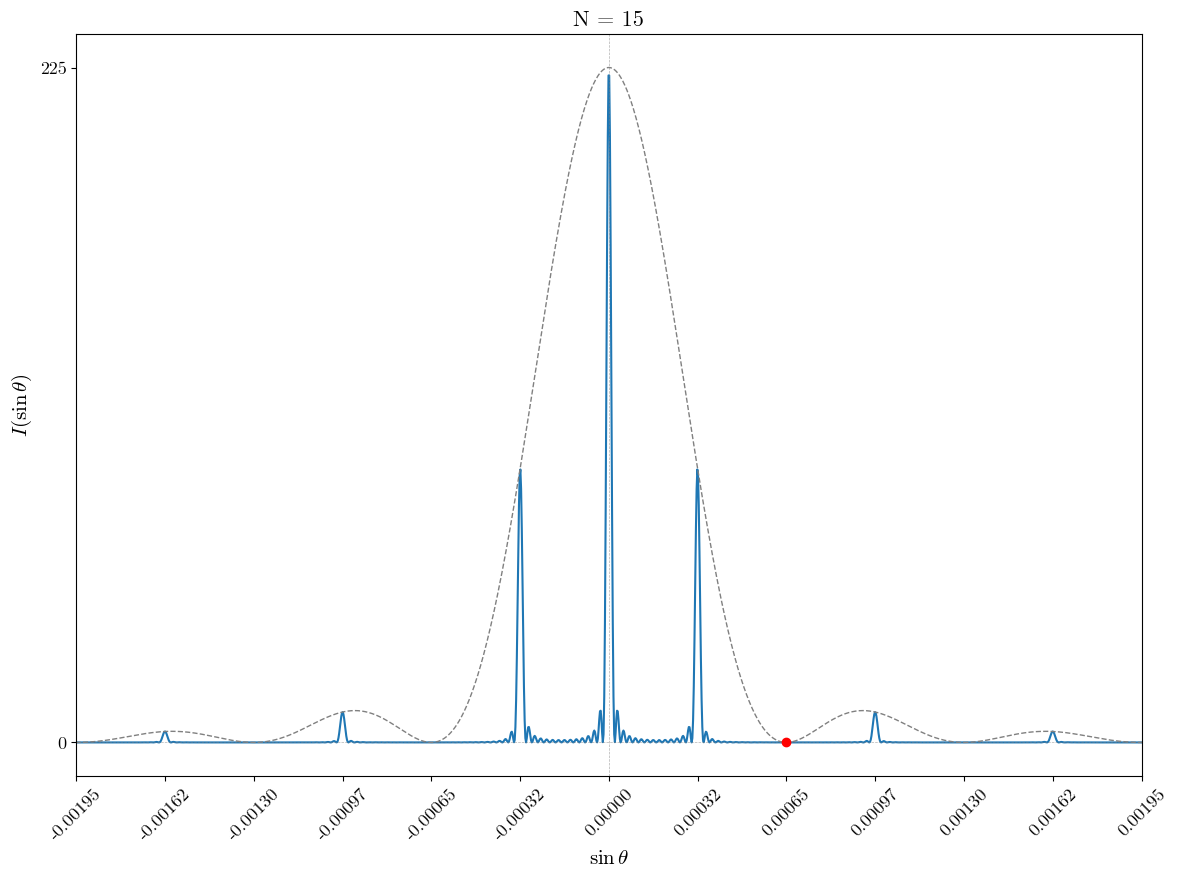

In [85]:
b = 1
d = 2
N = 15
lam = 650 * 1e-6  # если lam не определена ранее
k = 2 * np.pi / lam

sinT = np.linspace(-4 * lam / b, 4 * lam / b, 2000)

eps = k * b / 2 * sinT
eta = k * d / 2 * sinT

# Избегаем деления на ноль
eta_safe = np.where(np.abs(eta) < 1e-12, 1e-12, eta)

I_max = 1
I = I_max * np.sinc(eps / np.pi)**2
I_15 = I_max * np.sinc(eps / np.pi)**2 * (np.sin(N * eta_safe) / np.sin(eta_safe))**2

# Главные максимумы решётки (порядки)
main_max_pos = [n * lam / d for n in range(-6, 7)]
# Минимумы огибающей
min_pos = [n * lam / b for n in range(-4, 5)]

plt.figure(figsize=(12, 9))
plt.title("N = 15")

plt.plot(sinT, I_15)
plt.plot(sinT, N**2 * I, color='gray', linestyle='--', linewidth=1)

# Горизонтальная и вертикальная линии
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.6)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.6)

# Минимум огибающей
plt.scatter(lam / b, 0, color='red', zorder=5)

# Метки — все уникальные позиции, сортированные
all_ticks = sorted(set(main_max_pos + min_pos))
plt.xticks(all_ticks, [f"{t:.5f}" for t in all_ticks], rotation=45)
plt.xlabel(r"$\sin \theta$")
plt.yticks([0, N**2])
plt.ylabel(r"$I(\sin \theta)$")

plt.xlim(-3 * lam / b, 3 * lam / b)
plt.tight_layout()

plt.savefig('../graph/graph_N15.pdf', 
            format='pdf',
            dpi=300,
            bbox_inches='tight',  # обрезает лишние поля
            pad_inches=0.1)
plt.show()